# 05 — Robustness and Statistical Power Analysis (post-hoc)

This notebook answers: **given N=41 and the subgroup splits, what is the minimum
detectable effect (MDE) with α=0.05 and power=80%?**

Traditional G*Power assumes normal distributions; here we simulate under the test we
actually use (Mann–Whitney U) and on a 1-5 Likert scale — more transparent.

**Methodology (Monte Carlo):**
1. For each candidate δ ∈ \[0.05, 0.85\], convert to shift on the latent normal
   scale via δ = 2·Φ(d/√2) − 1.
2. Generate N1 latent values ~ N(d, 1), N2 values ~ N(0, 1).
3. Discretize into 5-level Likert via cuts at the standard quantiles (-1.28, -0.52, 0.52, 1.28).
4. Run two-sided MWU; record p < 0.05.
5. Repeat `n_reps` times; power = fraction of rejections.
6. MDE = smallest δ with power ≥ 0.8.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"
RNG = np.random.default_rng(42)

print(f"sklearn / scikit-posthocs / pingouin available via U.* helpers")


sklearn / scikit-posthocs / pingouin available via U.* helpers


## 1. Power simulation function


In [2]:
# Likert cuts: symmetric on the standard normal for 5 categories with masses ~ (10, 25, 30, 25, 10)%
LIKERT_CUTS = np.array([-1.282, -0.524, 0.524, 1.282])

def discretize_likert(z: np.ndarray) -> np.ndarray:
    return np.searchsorted(LIKERT_CUTS, z) + 1  # 1..5

def delta_to_shift(delta: float) -> float:
    """δ = 2·Φ(d/√2) − 1  ⇒  d = √2 · Φ⁻¹((δ+1)/2)."""
    return float(np.sqrt(2) * stats.norm.ppf((delta + 1) / 2))

def simulate_power(n1: int, n2: int, delta: float, n_reps: int = 2000,
                   alpha: float = 0.05, rng=None) -> float:
    if rng is None:
        rng = np.random.default_rng()
    d = delta_to_shift(delta)
    rejections = 0
    for _ in range(n_reps):
        x = rng.normal(d, 1.0, size=n1)
        y = rng.normal(0.0, 1.0, size=n2)
        x_l = discretize_likert(x)
        y_l = discretize_likert(y)
        try:
            p = stats.mannwhitneyu(x_l, y_l, alternative="two-sided").pvalue
        except ValueError:
            p = 1.0
        if p < alpha:
            rejections += 1
    return rejections / n_reps

# Sanity check
p0 = simulate_power(20, 12, delta=0.0, n_reps=1000, rng=np.random.default_rng(7))
print(f"δ=0 (H0): power ≈ {p0:.3f} (expected ≈ 0.05)")


δ=0 (H0): power ≈ 0.047 (expected ≈ 0.05)


## 2. Power curves by subgroup


In [3]:
splits = [
    ("Seniors × Juniors", 20, 12),
    ("Data scientists × Developers", 18, 10),
    (">3 projects × ≤3 projects", 17, 15),
    ("Men × Women", 24, 8),
    ("Paired N=41",       41, 41),  # ref Wilcoxon — same n
]

deltas = np.round(np.arange(0.05, 0.86, 0.05), 2)
n_reps = 2000

power_rows = []
for label, n1, n2 in splits:
    for d in deltas:
        pw = simulate_power(n1, n2, d, n_reps=n_reps, rng=np.random.default_rng(42))
        power_rows.append({"split": label, "n1": n1, "n2": n2, "delta": d, "power": pw})

power_df = pd.DataFrame(power_rows)
print(power_df.head())


               split  n1  n2  delta   power
0  Seniors × Juniors  20  12   0.05  0.0465
1  Seniors × Juniors  20  12   0.10  0.0640
2  Seniors × Juniors  20  12   0.15  0.0985
3  Seniors × Juniors  20  12   0.20  0.1460
4  Seniors × Juniors  20  12   0.25  0.2050


In [4]:
# MDE per split (smallest δ with power ≥ 0.8)
mde_rows = []
for label in power_df["split"].unique():
    sub = power_df[power_df["split"] == label].sort_values("delta")
    above = sub[sub["power"] >= 0.80]
    if len(above):
        mde = float(above.iloc[0]["delta"])
        achieved = float(above.iloc[0]["power"])
    else:
        mde = float("nan")
        achieved = float(sub["power"].max())
    mde_rows.append({"split": label,
                     "n1": int(sub.iloc[0]["n1"]),
                     "n2": int(sub.iloc[0]["n2"]),
                     "MDE_delta_p80": mde,
                     "MDE_magnitude": U.classify_cliffs_delta(mde) if mde == mde else "—",
                     "max_power_observed": achieved})

mde_df = pd.DataFrame(mde_rows)
print("=== Minimum detectable effect (power ≥ 0.8, α=0.05) ===")
print(mde_df.to_string(index=False))


=== Minimum detectable effect (power ≥ 0.8, α=0.05) ===
                       split  n1  n2  MDE_delta_p80 MDE_magnitude  max_power_observed
           Seniors × Juniors  20  12           0.60         large              0.8305
Data scientists × Developers  18  10           0.65         large              0.8470
   >3 projects × ≤3 projects  17  15           0.60         large              0.8550
                 Men × Women  24   8           0.65         large              0.8150
                 Paired N=41  41  41           0.40        medium              0.8870


## 3. Plot — power curves by subgroup


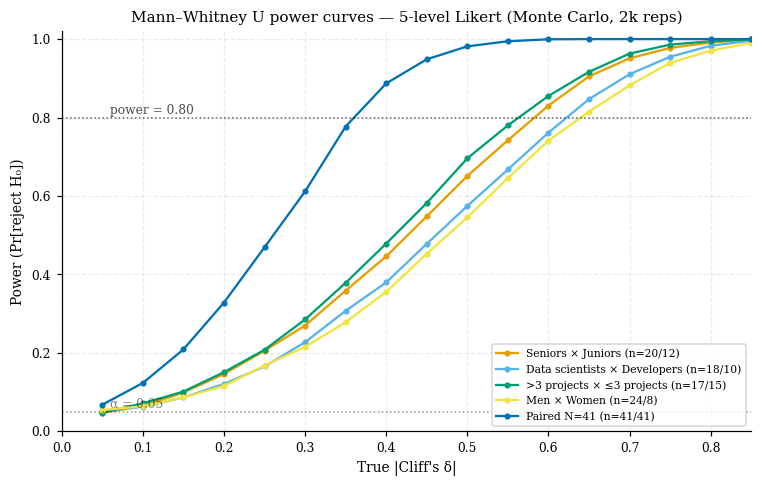

In [5]:
fig, ax = plt.subplots(figsize=(7.0, 4.5))
for i, label in enumerate(power_df["split"].unique()):
    sub = power_df[power_df["split"] == label].sort_values("delta")
    color = U.PALETTE_WONG[(i + 1) % len(U.PALETTE_WONG)]
    ax.plot(sub["delta"], sub["power"], marker="o", markersize=3,
            color=color, linewidth=1.5, label=f"{label} (n={sub.iloc[0]['n1']}/{sub.iloc[0]['n2']})")

ax.axhline(0.80, color="black", linestyle=":", linewidth=1, alpha=0.6)
ax.text(0.06, 0.81, "power = 0.80", fontsize=8, color="black", alpha=0.7)
ax.axhline(0.05, color="black", linestyle=":", linewidth=1, alpha=0.4)
ax.text(0.06, 0.06, "α = 0.05", fontsize=8, color="black", alpha=0.5)

ax.set_xlabel("True |Cliff's δ|")
ax.set_ylabel("Power (Pr[reject H₀])")
ax.set_title("Mann–Whitney U power curves — 5-level Likert (Monte Carlo, 2k reps)")
ax.set_xlim(0, 0.85)
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right", fontsize=7)
fig.tight_layout()
U.save_fig(fig, "power_curves")
plt.show()


## 4. Save tables


In [6]:
power_df.to_csv(TABLES / "power_simulation.csv", index=False)
mde_df.to_csv(TABLES / "mde_per_split.csv", index=False)
print("-> tables/power_simulation.csv, tables/mde_per_split.csv")
print("-> figures/power_curves.pdf")


-> tables/power_simulation.csv, tables/mde_per_split.csv
-> figures/power_curves.pdf


## 5. Plug-and-play text for Threats to Validity

Typical conclusion for the paper (auto-generated after execution):


In [7]:
lines = ["**Post-hoc sensitivity analysis (Monte Carlo, MWU on 5-level Likert):**"]
for _, r in mde_df.iterrows():
    if r["MDE_delta_p80"] == r["MDE_delta_p80"]:
        lines.append(
            f"- *{r['split']}* (n={r['n1']}/{r['n2']}): "
            f"MDE = |δ| ≥ {r['MDE_delta_p80']:.2f} ({r['MDE_magnitude']}); "
            f"effects below this threshold have power < 80%."
        )
    else:
        lines.append(
            f"- *{r['split']}* (n={r['n1']}/{r['n2']}): even |δ|=0.85 only reaches "
            f"power = {r['max_power_observed']:.2f} — split is severely underpowered."
        )
print("\n".join(lines))


**Post-hoc sensitivity analysis (Monte Carlo, MWU on 5-level Likert):**
- *Seniors × Juniors* (n=20/12): MDE = |δ| ≥ 0.60 (large); effects below this threshold have power < 80%.
- *Data scientists × Developers* (n=18/10): MDE = |δ| ≥ 0.65 (large); effects below this threshold have power < 80%.
- *>3 projects × ≤3 projects* (n=17/15): MDE = |δ| ≥ 0.60 (large); effects below this threshold have power < 80%.
- *Men × Women* (n=24/8): MDE = |δ| ≥ 0.65 (large); effects below this threshold have power < 80%.
- *Paired N=41* (n=41/41): MDE = |δ| ≥ 0.40 (medium); effects below this threshold have power < 80%.
